Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data collection and processing

In [2]:
#loading csv data into a pandas DataFrame
gold_data=pd.read_csv('/content/gld_price_data.csv')

In [4]:
#print first 5 rows into the dataFrame
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [6]:
#print last 5 rows of dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [8]:
#numer of rows and columns
gold_data.shape

(2290, 6)

In [10]:
#getting some basic information about data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [12]:
#checking the nunmber of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [14]:
#getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
1.Positive correlation
2.Negative correlation

In [22]:
correlation=gold_data.corr

In [24]:
print(gold_data.shape)
print(gold_data.dtypes)

(2290, 6)
Date        object
SPX        float64
GLD        float64
USO        float64
SLV        float64
EUR/USD    float64
dtype: object


In [27]:
numeric_data = gold_data.drop(columns=['Date'])

In [29]:
correlation = numeric_data.corr()

<Axes: >

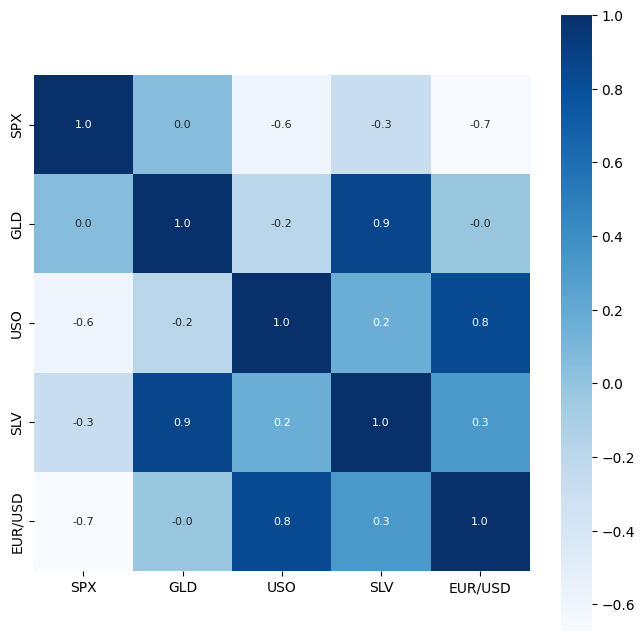

In [31]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True,
            fmt='.1f', annot=True,
            annot_kws={'size':8}, cmap='Blues')

In [34]:
#correlatrion values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_1016/1384357783.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

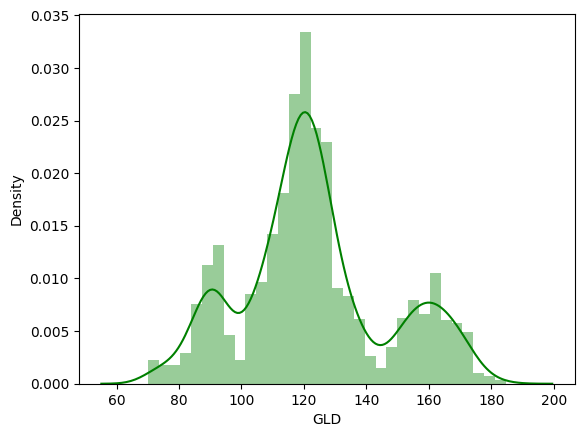

In [36]:
#checking the distribution of gold price
sns.distplot(gold_data['GLD'],color='green')

splitting the features and the target


In [38]:
X=gold_data.drop(['Date','GLD'],axis=1)
Y=gold_data['GLD']

In [41]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [43]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


splitting into training data and test data

In [45]:
X_train, X_test,Y_train,Y_test = train_test_split(X , Y, test_size=0.2,random_state=2)

Model Training:

Random Forest Regressor

In [47]:
regressor=RandomForestRegressor(n_estimators=100)

In [49]:
#training thge model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [51]:
#prediction on test data
test_data_prediction=regressor.predict(X_test)

In [53]:
print(test_data_prediction)

[168.47659873  81.98749978 115.7648001  127.58470077 120.65940114
 154.74619701 150.12499783 126.10030023 117.60739871 125.98070063
 116.75490107 172.36090102 141.32259845 167.80549861 115.13680004
 117.83260059 139.82540316 169.59450052 159.83160317 157.98829883
 155.09630012 125.47140035 175.73510021 157.52740311 125.16030045
  94.11479996  77.91420039 121.14419975 119.17089954 167.54220014
  88.42879999 125.23470053  91.13720055 117.61200024 121.15509922
 136.40430042 115.65710126 115.37980069 147.92229951 107.46730075
 104.55580225  87.26159798 126.43590069 117.93709981 153.43329913
 119.554      108.26210062 108.1202985   93.29140082 127.10719799
  74.8902006  113.696699   121.20470026 111.22859882 118.96379884
 121.16989912 159.81720071 167.38820113 147.14569701  85.85989834
  94.27550061  86.88579878  90.46550022 118.8884009  126.32950066
 127.4630999  169.12709998 122.16939948 117.55689903  98.36680044
 168.27690157 143.39459869 131.77100241 121.07500197 121.64579946
 119.70970

In [55]:
#R squared error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error :",error_score)

R squared error : 0.989326643295551


Compare the actual values and predicted values in a plot

In [57]:
Y_test=list(Y_test)

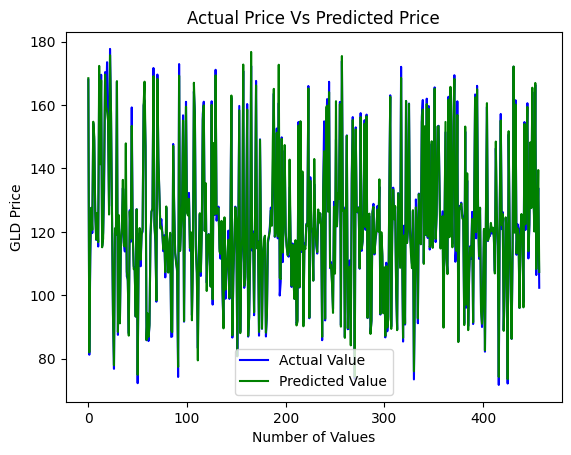

In [61]:
plt.plot(Y_test,color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='green',label='Predicted Value')
plt.title("Actual Price Vs Predicted Price")
plt.xlabel('Number of Values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()